# 准备数据

In [1]:
# 过滤Alphalens的warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [3]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi1000")

In [4]:
# 设置任务参数
name = "lgb"
index_symbol: str = "000852.SSE"
start: str = "2016-01-01"
end: str = "2025-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [5]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [6]:
# 加载模块
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_cs_norm
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158

In [7]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [8]:
df

datetime,open,high,low,close,volume,turnover,open_interest,vwap,vt_symbol
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,str
2015-09-23 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""002228.SZSE"""
2015-09-24 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""002228.SZSE"""
2015-09-25 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""002228.SZSE"""
2015-09-28 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""002228.SZSE"""
2015-09-29 00:00:00,1.0,1.0,1.0,1.0,0.0,0.0,0.0,NaN,"""002228.SZSE"""
…,…,…,…,…,…,…,…,…,…
2026-01-05 00:00:00,1.186458,1.193453,1.15826,1.182669,3.4408e6,5.54148665e8,0.0,161.050883,"""688536.SSE"""
2026-01-06 00:00:00,1.180337,1.226534,1.170574,1.224129,4.5095e6,7.44551117e8,0.0,165.107326,"""688536.SSE"""
2026-01-07 00:00:00,1.231197,1.313316,1.231197,1.275061,6.9462e6,1.2185e9,0.0,175.423474,"""688536.SSE"""


In [9]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=("2016-01-01", "2020-12-31"),
    valid_period=("2021-01-01", "2022-12-31"),
    test_period=("2023-01-01", "2025-12-31"),
)

In [10]:
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))

In [11]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [12]:
# 准备特征和标签数据
dataset.prepare_data(filters, max_workers=3)

# 应用数据预处理器
dataset.process_data()

2026-06-30 10:56:05 开始计算表达式因子特征


100%|██████████| 159/159 [2:59:16<00:00, 67.65s/it]   


2026-06-30 13:55:25 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-06-30 13:55:38 开始筛选成分股数据


100%|██████████| 2637/2637 [00:21<00:00, 120.38it/s]


Dropped 6.3% entries from factor data: 0.4% in forward returns computation and 5.8% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,0.000000,0.925373,0.089778,0.115886,227800,10.000026
2.0,0.001028,0.942598,0.213691,0.163548,227800,10.000026
3.0,0.011581,0.965429,0.295326,0.187974,227800,10.000026
4.0,0.019260,0.976284,0.365491,0.200740,227800,10.000026
5.0,0.026252,0.984252,0.432784,0.205994,227800,10.000026
6.0,0.033613,0.990599,0.501375,0.204911,227794,9.999763
7.0,0.044639,1.000000,0.574352,0.197252,227800,10.000026
8.0,0.062500,1.000000,0.655948,0.181126,227800,10.000026
9.0,0.094397,1.000000,0.752352,0.152965,227800,10.000026


Returns Analysis


,1D,5D,10D
Ann. alpha,0.029,-0.022,-0.006
beta,-0.034,-0.022,-0.015
Mean Period Wise Return Top Quantile (bps),5.166,-2.908,-1.834
Mean Period Wise Return Bottom Quantile (bps),-3.651,-2.375,-2.381
Mean Period Wise Spread (bps),8.817,-0.493,0.574


<Figure size 640x480 with 0 Axes>

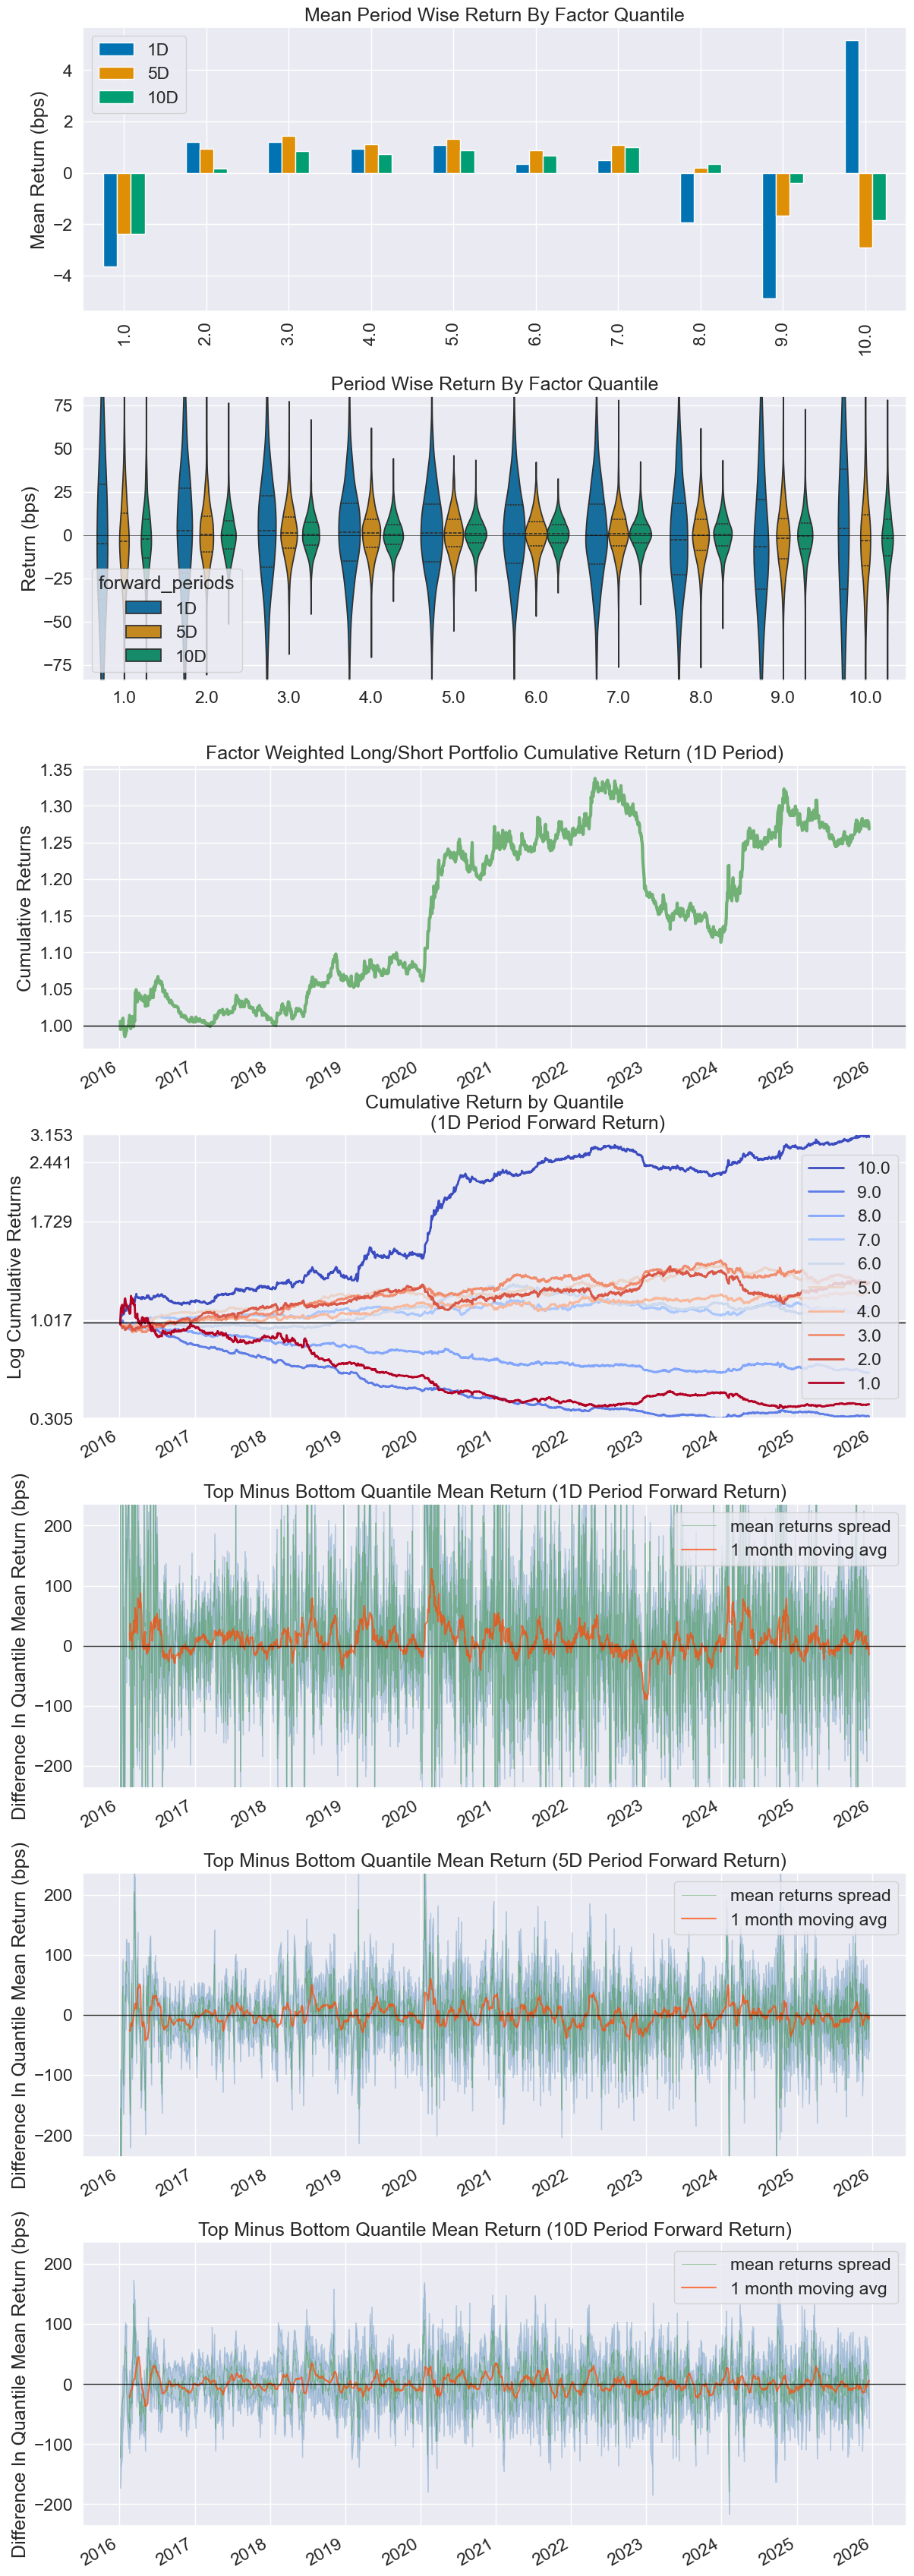

Information Analysis


,1D,5D,10D
IC Mean,-0.031,-0.017,-0.010
IC Std.,0.140,0.124,0.121
Risk-Adjusted IC,-0.219,-0.136,-0.079
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


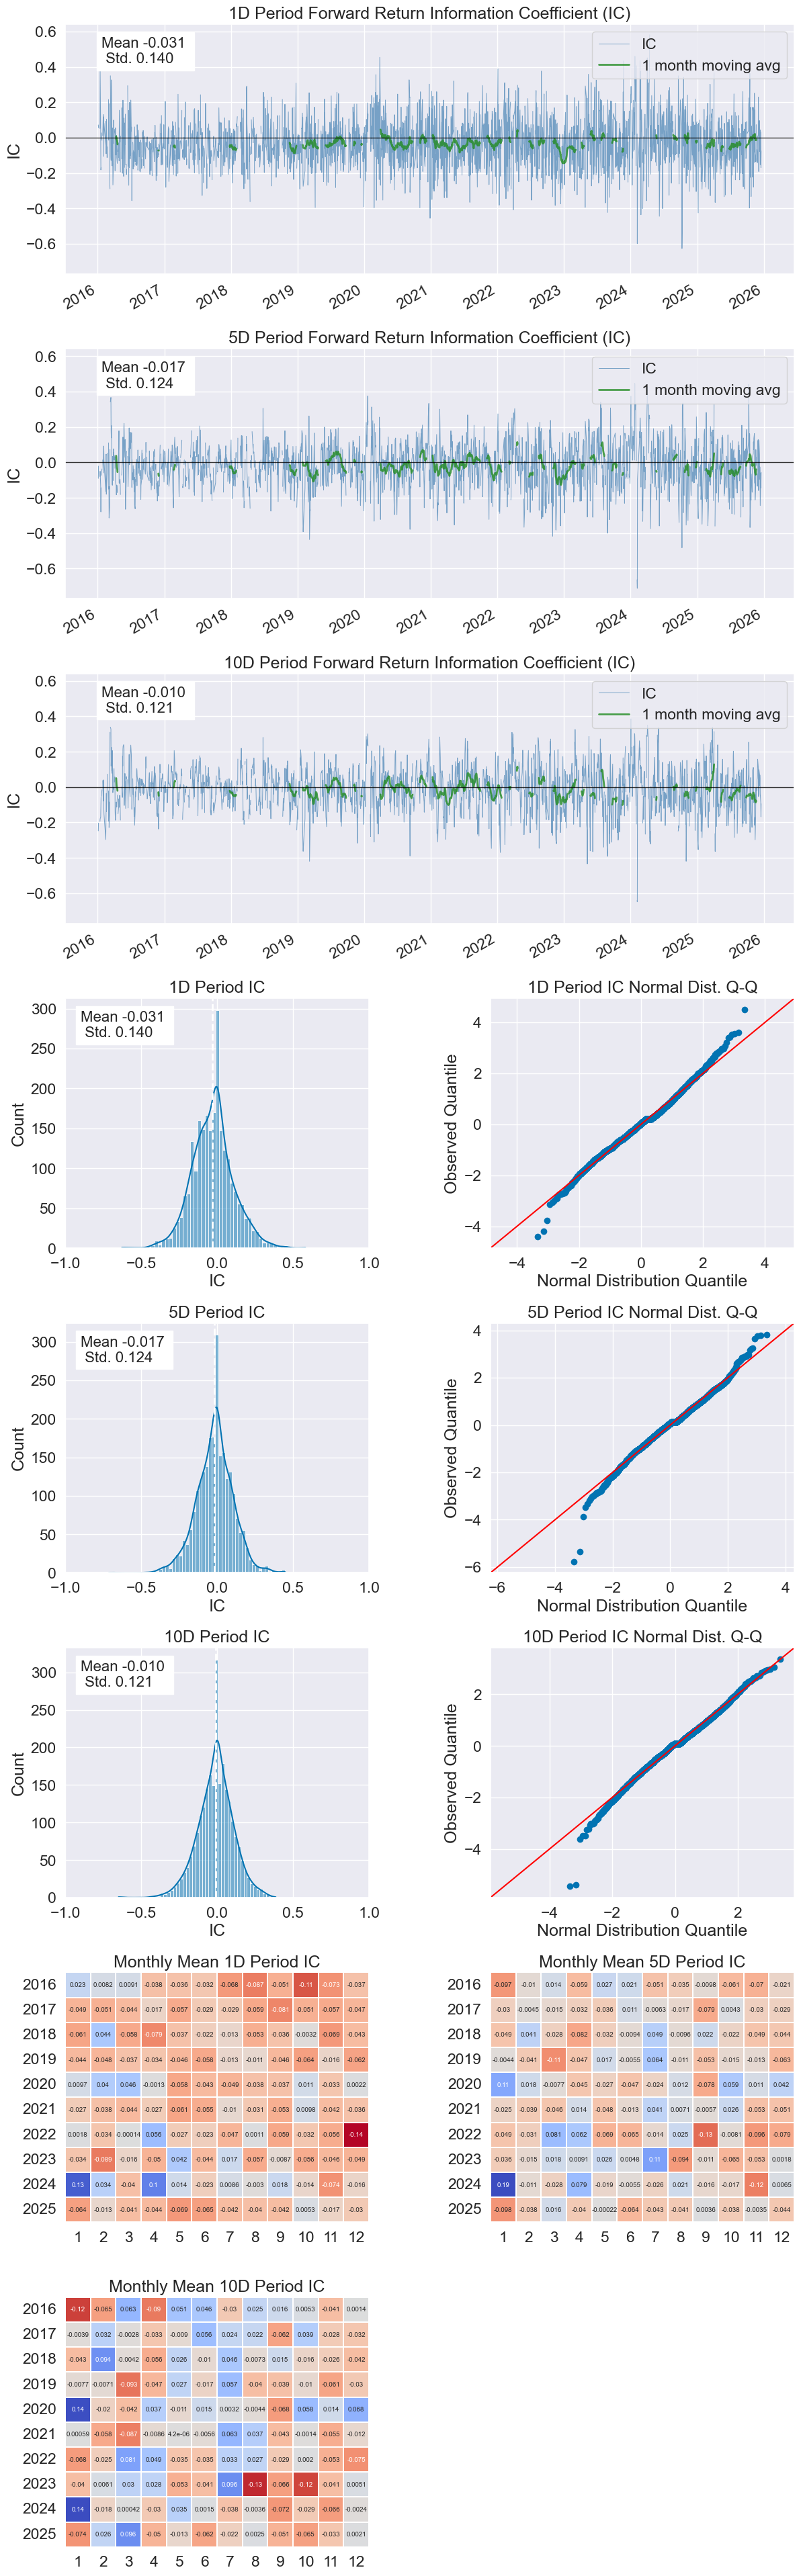

d:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.553,0.773,0.781
Quantile 2.0 Mean Turnover,0.759,0.902,0.900
Quantile 3.0 Mean Turnover,0.821,0.898,0.899
Quantile 4.0 Mean Turnover,0.847,0.896,0.897
Quantile 5.0 Mean Turnover,0.858,0.895,0.896
Quantile 6.0 Mean Turnover,0.859,0.896,0.897
Quantile 7.0 Mean Turnover,0.854,0.897,0.899
Quantile 8.0 Mean Turnover,0.836,0.900,0.900
Quantile 9.0 Mean Turnover,0.793,0.899,0.898
Quantile 10.0 Mean Turnover,0.684,0.897,0.893


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.596,0.015,0.031


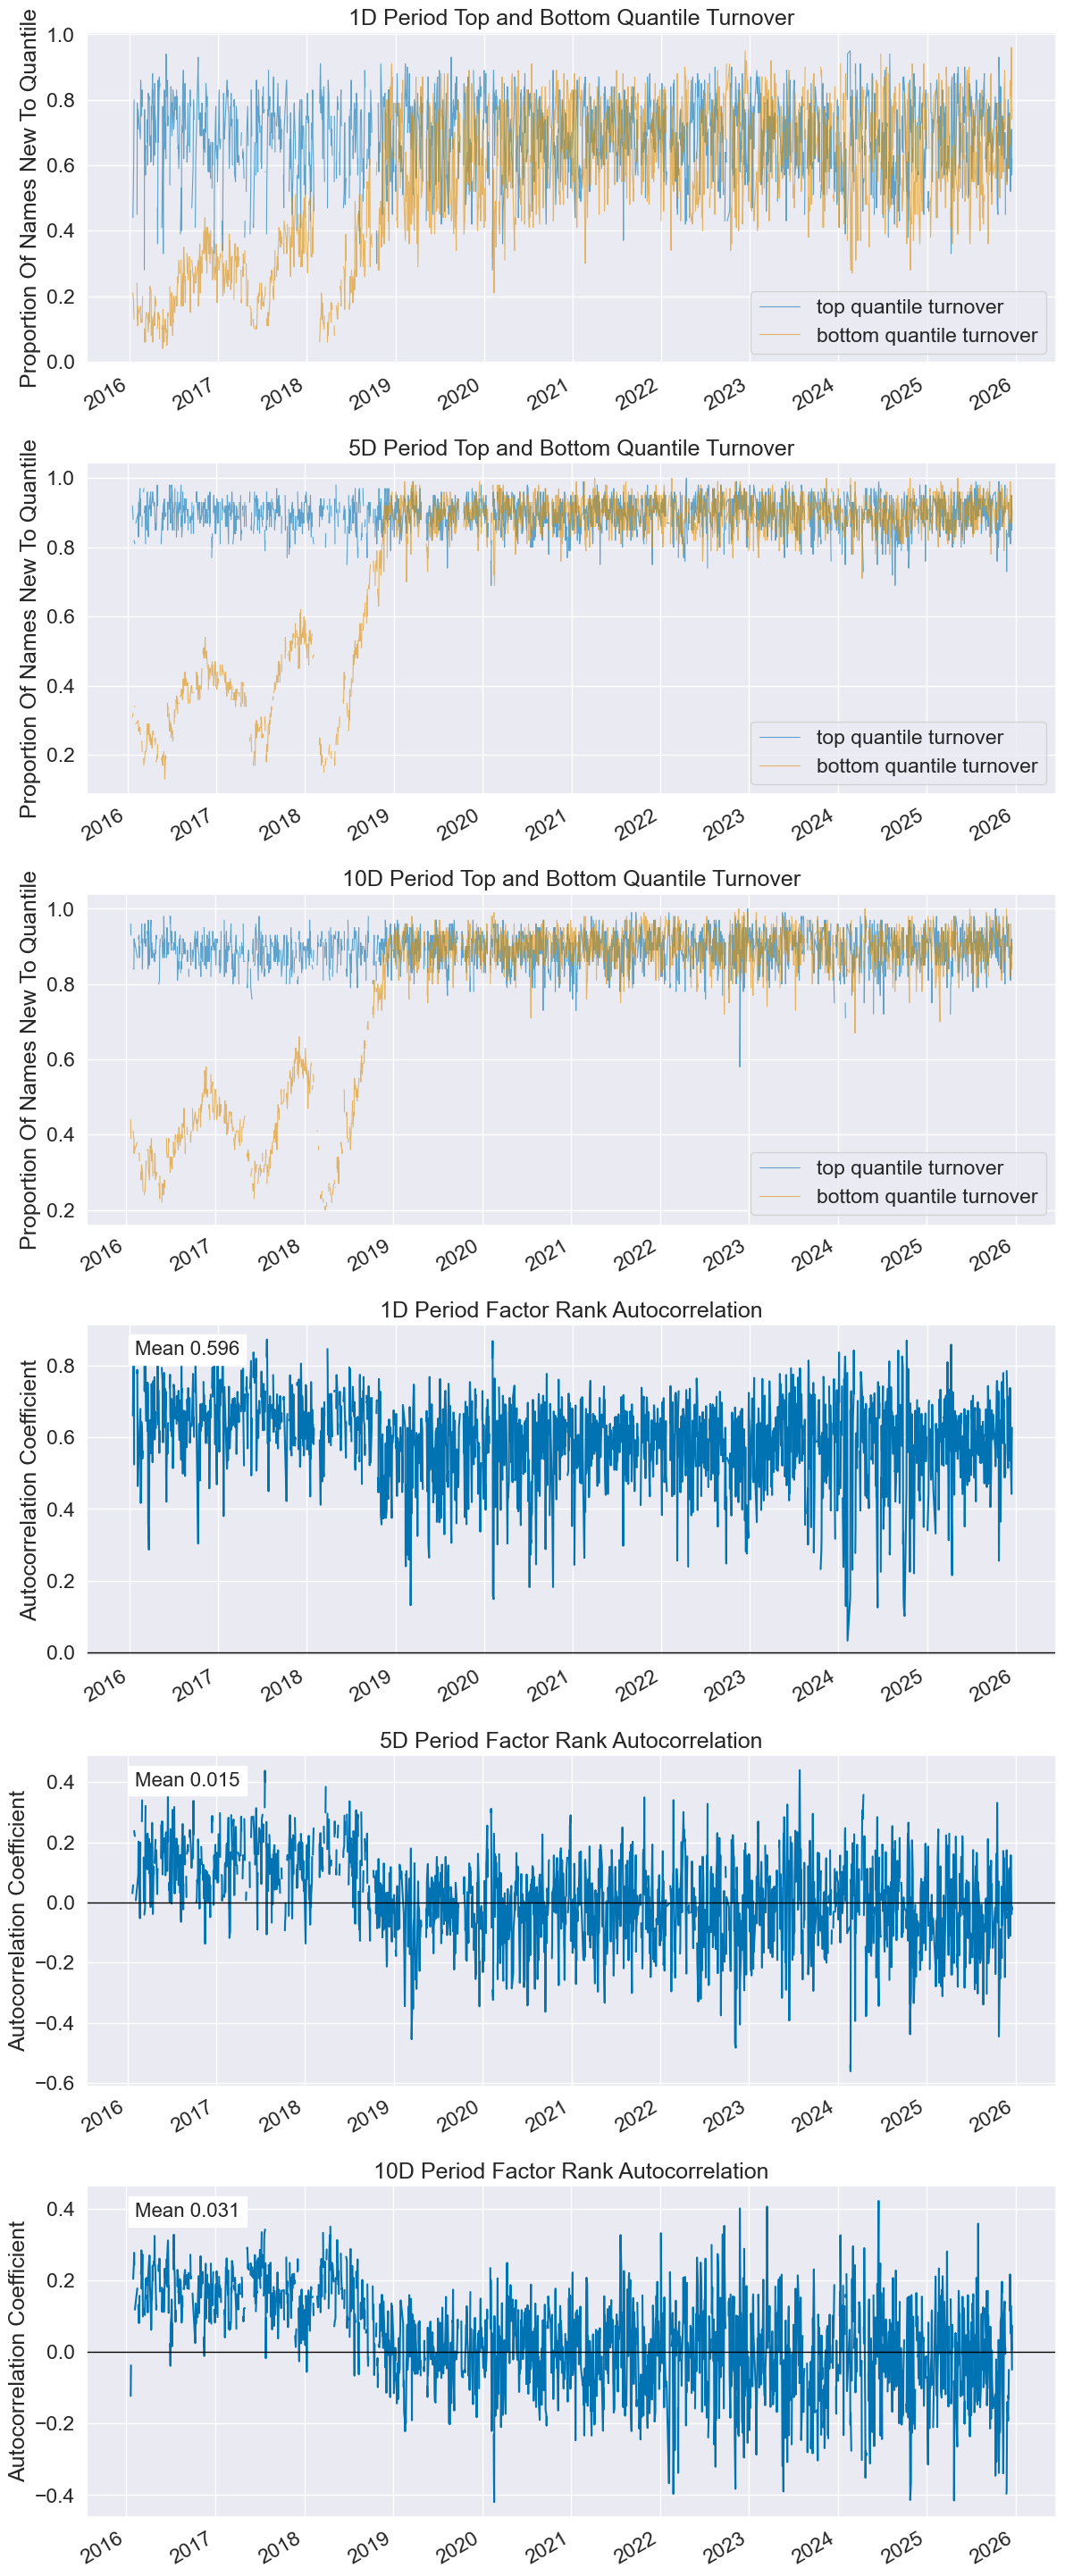

In [13]:
# 特征表现分析
dataset.show_feature_performance("rsv_5")

In [14]:
# 数据预处理
dataset.process_data()

In [15]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [16]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [17]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [18]:
# 创建模型对象
model: AlphaModel = LgbModel()

In [19]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.467798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32138
[LightGBM] [Info] Number of data points in the train set: 1217997, number of used features: 151
[LightGBM] [Info] Start training from score 0.000000
[1]	train's l2: 0.997471	valid's l2: 0.998645
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 0.996041	valid's l2: 0.998323
[3]	train's l2: 0.994891	valid's l2: 0.998087
[4]	train's l2: 0.993874	valid's l2: 0.997905
[5]	train's l2: 0.99295	valid's l2: 0.997787
[6]	train's l2: 0.992174	valid's l2: 0.99772
[7]	train's l2: 0.991443	valid's l2: 0.997609
[8]	train's l2: 0.990758	valid's l2: 0.997557
[9]	train's l2: 0.99012	valid's l2: 0.99754
[10]	train's l2: 0.989546	valid's l2: 0.997493
[11]	train's l2: 0.989016	valid's l2: 0.997525
[12]	train's l2: 0.988533	valid's l2: 0.997507
[13]	train's l2: 0.988039	valid's l2: 0.99

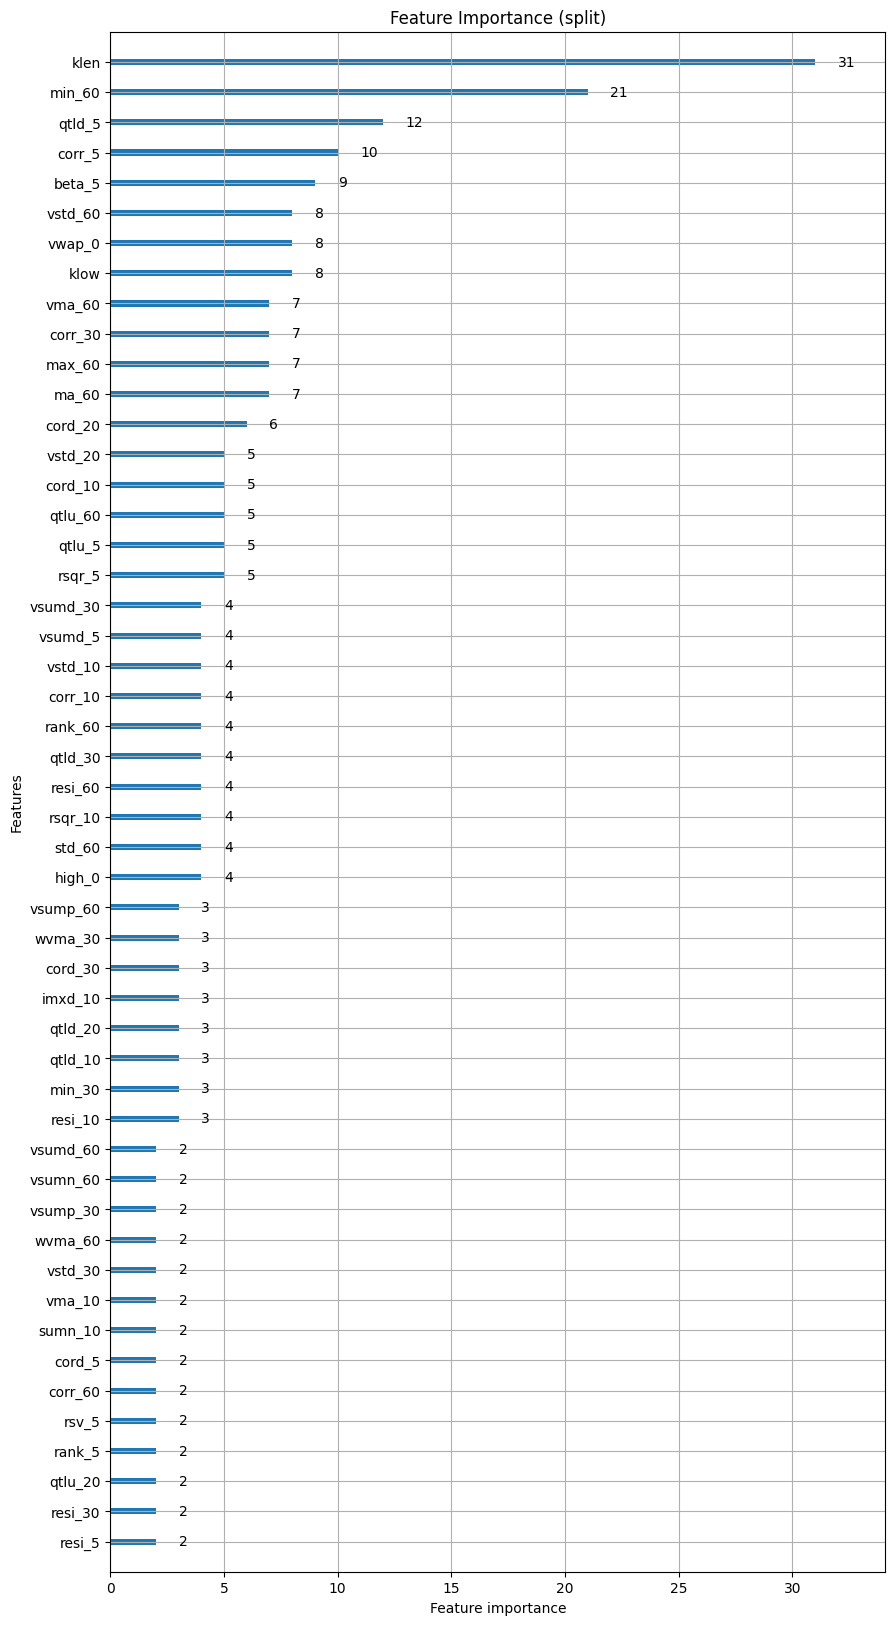

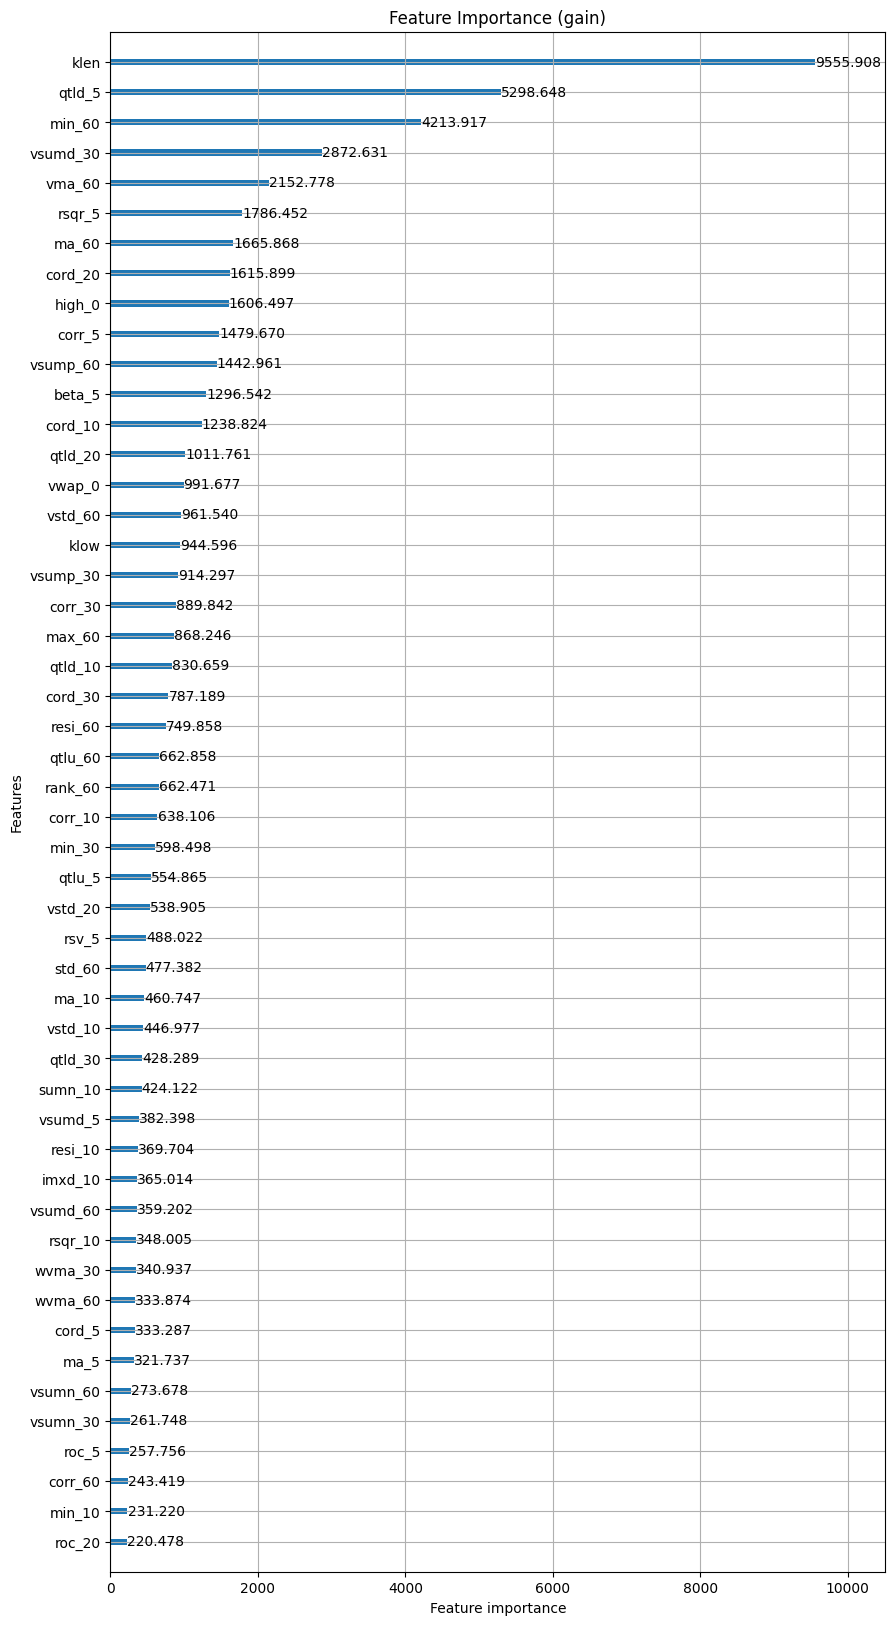

In [20]:
# 查看模型细节
model.detail()

In [21]:
# 保存模型
lab.save_model(name, model)

# 预测信号

In [22]:
model: AlphaModel = lab.load_model(name)

In [23]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

Dropped 1.5% entries from factor data: 1.4% in forward returns computation and 0.1% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1.0,-1.613307,0.002890,-0.068450,0.073432,72786,10.165642
2.0,-0.274235,0.018194,-0.025349,0.020632,71434,9.976816
3.0,-0.237515,0.023733,-0.013128,0.016692,71305,9.958799
4.0,-0.234663,0.029621,-0.004998,0.015641,71458,9.980168
5.0,-0.219037,0.047028,0.001666,0.013756,71698,10.013687
6.0,-0.203601,0.059517,0.007561,0.013060,71572,9.996089
7.0,-0.186963,0.074262,0.013084,0.012398,71679,10.011034
8.0,-0.167357,0.100119,0.018869,0.012100,71523,9.989246
9.0,-0.144540,0.115209,0.025739,0.012089,71733,10.018575


Returns Analysis


,1D,5D,10D
Ann. alpha,0.587,0.316,0.215
beta,-0.044,-0.023,-0.028
Mean Period Wise Return Top Quantile (bps),7.860,4.538,3.742
Mean Period Wise Return Bottom Quantile (bps),-14.899,-10.235,-7.379
Mean Period Wise Spread (bps),22.759,14.814,11.166


<Figure size 640x480 with 0 Axes>

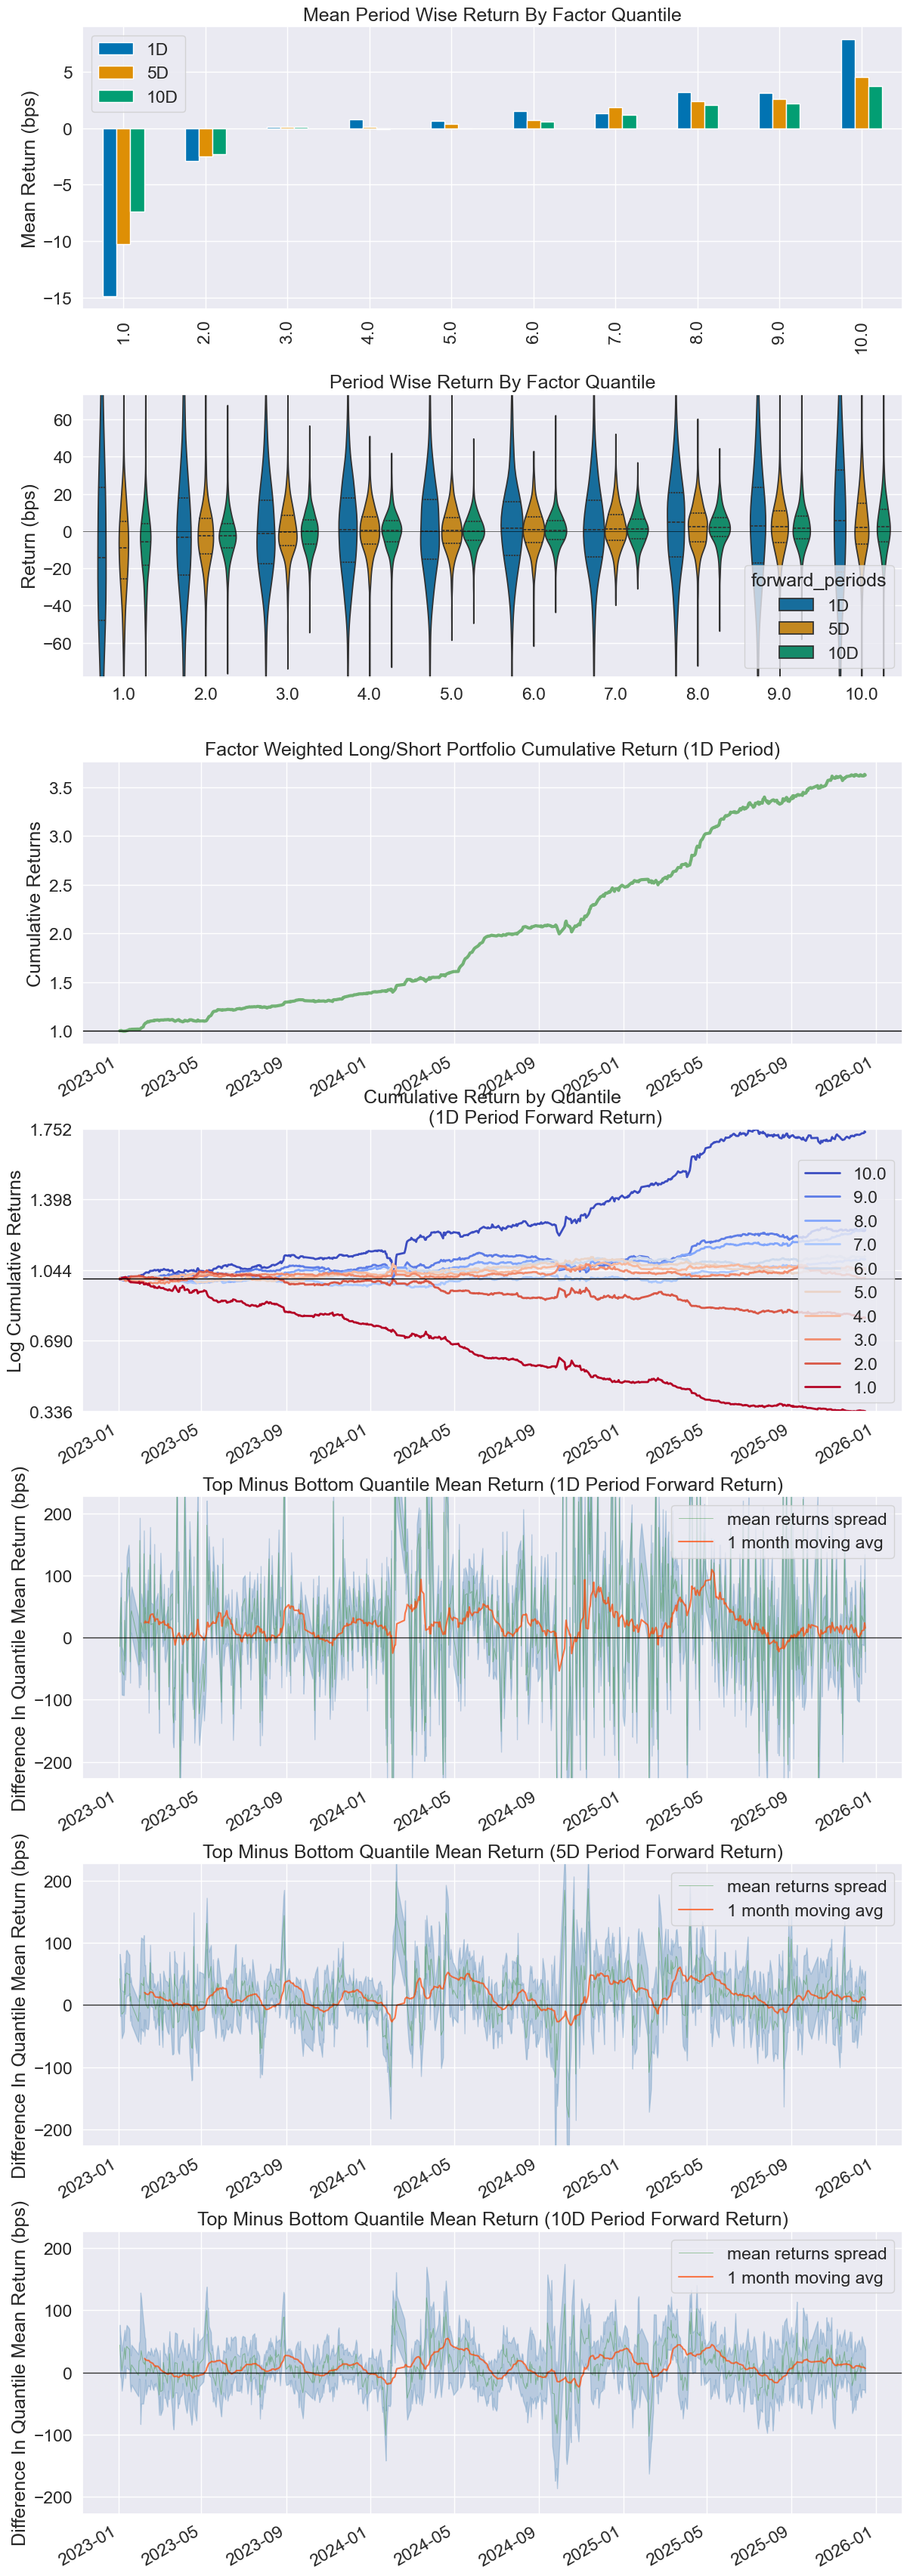

Information Analysis


,1D,5D,10D
IC Mean,0.046,0.058,0.062
IC Std.,0.115,0.108,0.112
Risk-Adjusted IC,0.397,0.534,0.550
t-stat(IC),NaN,NaN,NaN
p-value(IC),NaN,NaN,NaN
IC Skew,NaN,NaN,NaN
IC Kurtosis,NaN,NaN,NaN


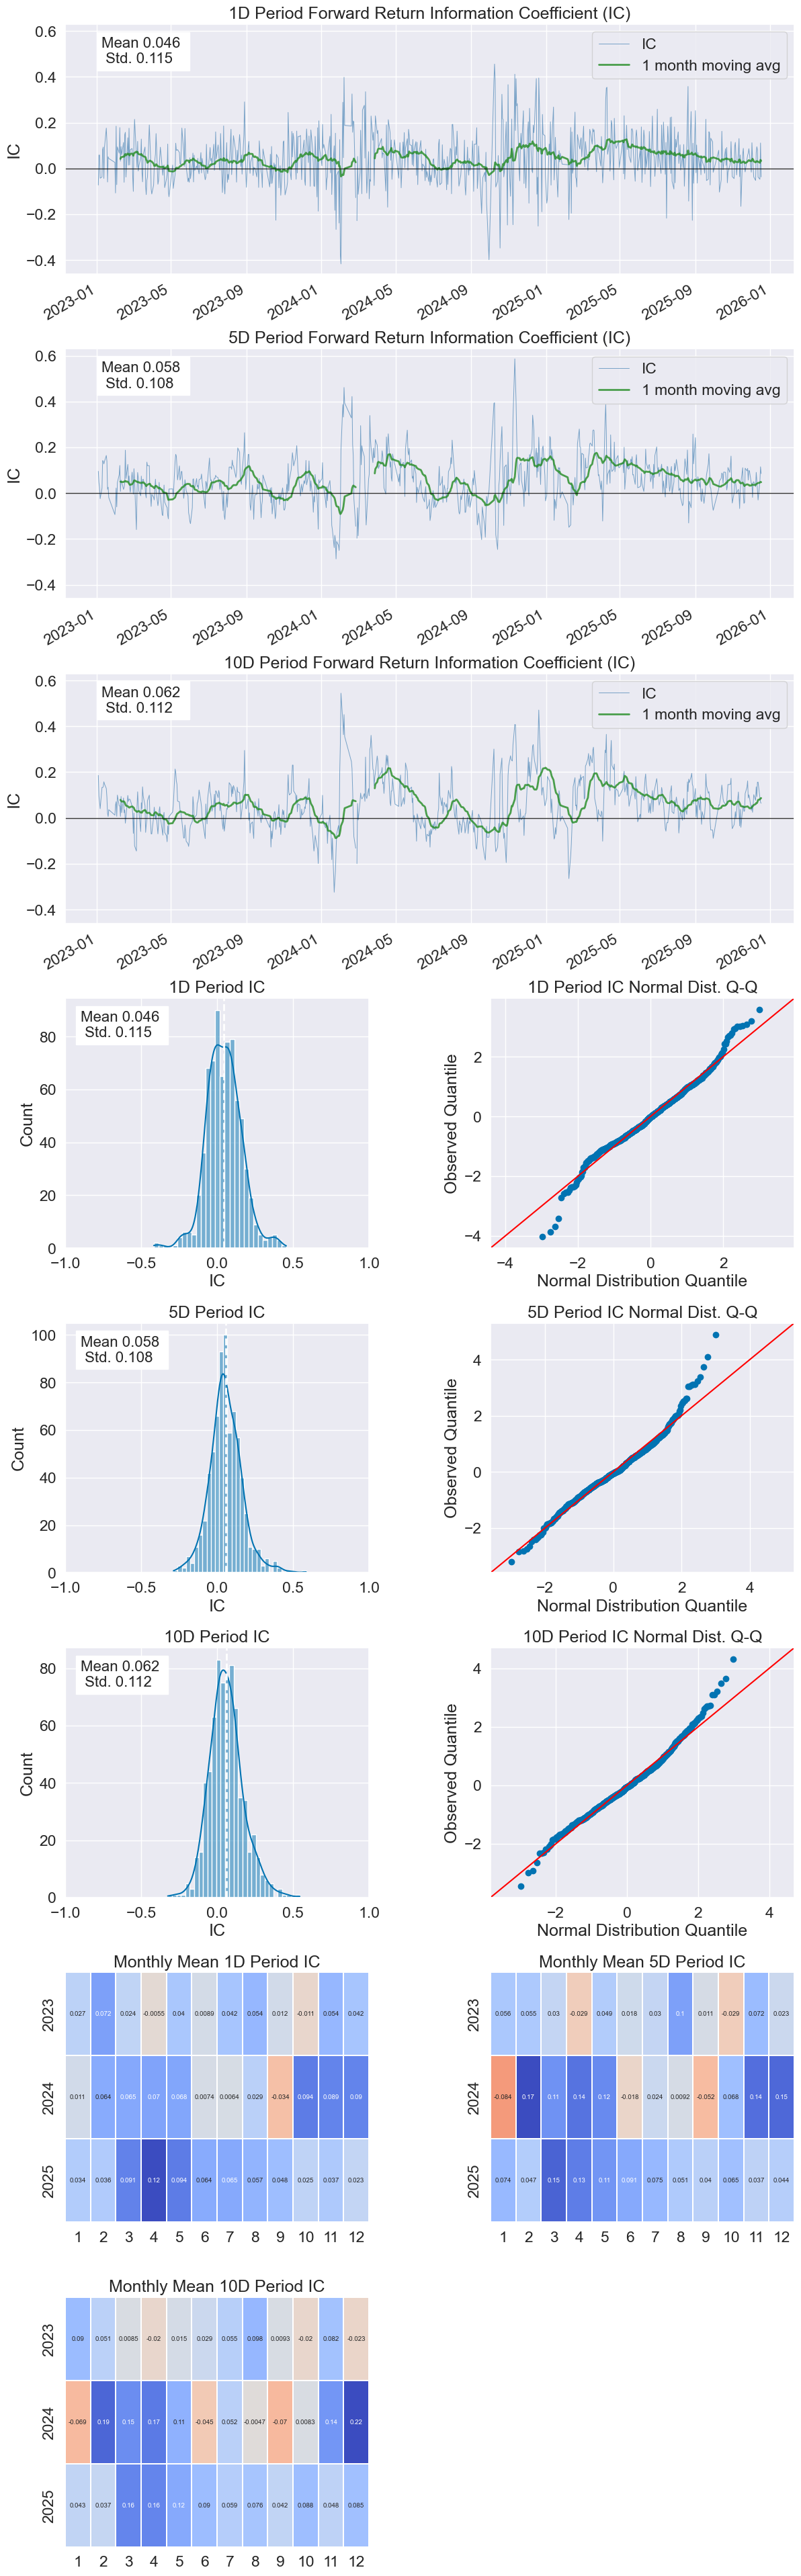

d:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1.0 Mean Turnover,0.456,0.726,0.804
Quantile 2.0 Mean Turnover,0.650,0.807,0.846
Quantile 3.0 Mean Turnover,0.722,0.846,0.869
Quantile 4.0 Mean Turnover,0.750,0.860,0.876
Quantile 5.0 Mean Turnover,0.761,0.865,0.882
Quantile 6.0 Mean Turnover,0.767,0.871,0.887
Quantile 7.0 Mean Turnover,0.770,0.872,0.886
Quantile 8.0 Mean Turnover,0.749,0.859,0.877
Quantile 9.0 Mean Turnover,0.685,0.825,0.849
Quantile 10.0 Mean Turnover,0.445,0.717,0.775


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.728,0.398,0.274


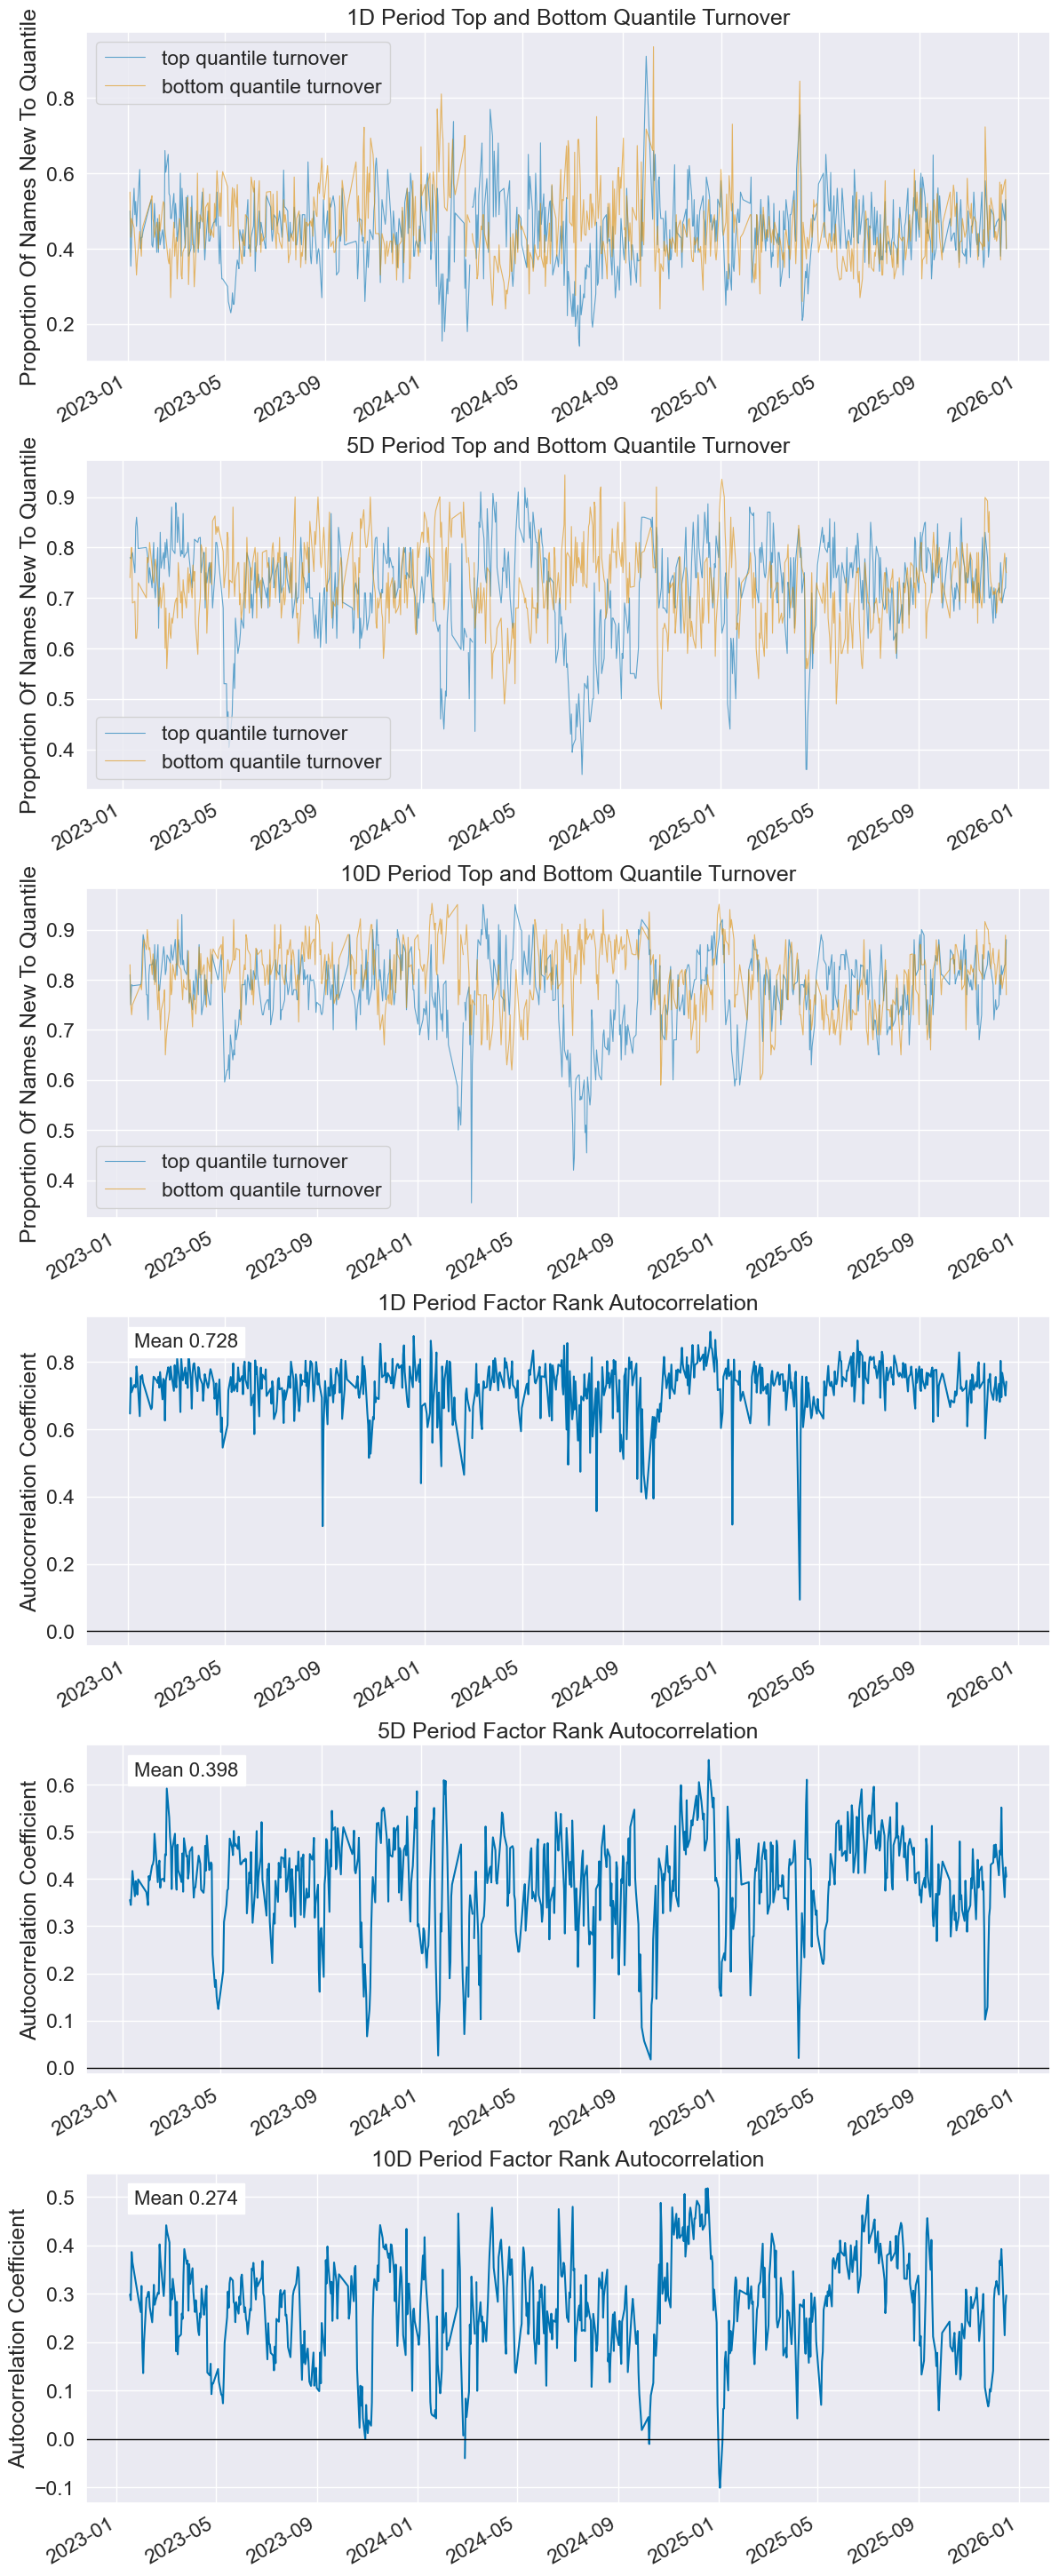

In [24]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [25]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [26]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [27]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [28]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [29]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2023, 1, 1),
    end=datetime(2025, 12, 31),
    capital=100_000_000
)

# 添加策略实例
setting = {"top_k": 225, "n_drop": 20, "min_days": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [30]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-06-30 14:06:43 开始加载历史数据


100%|██████████| 2637/2637 [00:23<00:00, 113.03it/s]

2026-06-30 14:07:07 部分合约历史数据为空：['600069.SSE', '600275.SSE', '600723.SSE', '600687.SSE', '600978.SSE', '000662.SZSE', '002619.SZSE', '300038.SZSE', '300431.SZSE', '600175.SSE', '300216.SZSE', '000760.SZSE', '002684.SZSE', '600680.SSE', '002447.SZSE', '600652.SSE', '000018.SZSE', '600090.SSE', '600555.SSE', '600856.SSE', '002071.SZSE', '603996.SSE', '600634.SSE', '002711.SZSE', '300156.SZSE', '002604.SZSE', '002147.SZSE', '300064.SZSE', '601313.SSE', '600146.SSE', '600291.SSE', '000043.SZSE', '002509.SZSE', '002260.SZSE', '600401.SSE', '300178.SZSE', '600677.SSE', '300028.SZSE', '300362.SZSE', '300367.SZSE', '600701.SSE', '002464.SZSE', '002070.SZSE', '000673.SZSE', '600209.SSE', '000916.SZSE', '002359.SZSE', '000022.SZSE', '300090.SZSE', '002680.SZSE', '600093.SSE', '002143.SZSE', '002618.SZSE', '300312.SZSE', '000687.SZSE']


2026-06-30 14:07:07 所有历史数据加载完成
2026-06-30 14:07:07 策略初始化完成
2026-06-30 14:07:07 开始回放历史数据
2026-06-30 14:07:23 历史数据回放结束
2026-06-30 14:07:23 开始计算逐日盯市盈亏
2026-06-30 14:07:26 逐日盯市盈亏计算完成
2026-06-30 14:07:26 开始计算策略统计指标
2026-06-30 14:07:26 ------------------------------
2026-06-30 14:07:26 首个交易日：  2023-01-03
2026-06-30 14:07:26 最后交易日：  2025-12-31
2026-06-30 14:07:26 总交易日：  727
2026-06-30 14:07:26 盈利交易日：  385
2026-06-30 14:07:26 亏损交易日：  341
2026-06-30 14:07:26 起始资金：  100,000,000.00
2026-06-30 14:07:26 结束资金：  155,408,974.99
2026-06-30 14:07:26 总收益率：  55.41%
2026-06-30 14:07:26 年化收益：  18.29%
2026-06-30 14:07:26 最大回撤:   -42,971,627.18
2026-06-30 14:07:26 百分比最大回撤: -37.54%
2026-06-30 14:07:26 最长回撤天数:   294
2026-06-30 14:07:26 总盈亏：  55,408,974.99
2026-06-30 14:07:26 总手续费：  3,814,624.93
2026-06-30 14:07:26 总成交金额：  5,118,110,060.51
2026-06-30 14:07:26 总成交笔数：  27671
2026-06-30 14:07:26 日均盈亏：  76,215.92
2026-06-30 14:07:26 日均手续费：  5,247.08
2026-06-30 14:07:26 日均成交金额：  7,040,041.35
2026-06-30 14:07:26 日均成交笔

In [31]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)